In [1]:
ranges = [(0, 10), (11, 20), (21, 30), (31, 50), (50, 105)]  
frequencies = [61,4,3,2,1]

In [2]:
total_frequency = sum(frequencies)  
weighted_sum = 0  
  
for r, f in zip(ranges, frequencies):  
    mid_point = (r[0] + r[1]) / 2  # 计算范围的中点值  
    weighted_sum += mid_point * f  # 加权和  
  
average = weighted_sum / total_frequency  # 计算加权平均值  
print(f"平均值为: {average}")

平均值为: 8.47887323943662


In [8]:
total_frequency = sum(frequencies) 
for f in frequencies:
    result = f / total_frequency
    print(result)

0.8591549295774648
0.056338028169014086
0.04225352112676056
0.028169014084507043
0.014084507042253521


In [4]:
import numpy as np  
  
# 数值范围和频数  
ranges = [(0, 10), (11, 20), (21, 30), (31, 50), (50, 105)]  
frequencies = [61, 4, 3, 2, 1]  
  
# 计算累积频数  
cumulative_frequencies = np.cumsum(frequencies)  
  
# 查找中位数所在的范围  
total_frequency = sum(frequencies)  
median_index = np.where(cumulative_frequencies >= total_frequency / 2)[0][0]  
median_range = ranges[median_index]  
  
print(f"总频数: {total_frequency}")  
print(f"累积频数达到或超过一半时的索引: {median_index}")  
print(f"中位数所在的数值范围: {median_range}")

总频数: 71
累积频数达到或超过一半时的索引: 0
中位数所在的数值范围: (0, 10)


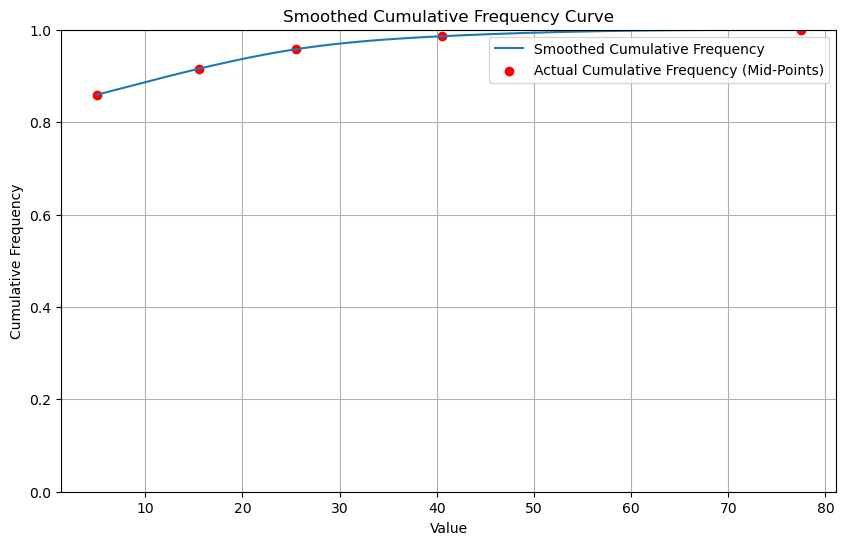

In [7]:
import numpy as np  
import matplotlib.pyplot as plt  
from scipy.interpolate import interp1d  
 
ranges = [(0, 10), (11, 20), (21, 30), (31, 50), (50, 105)]  
frequencies = [61, 4, 3, 2, 1]  
    
cumulative_frequencies = np.cumsum(frequencies)  
  

mid_points = np.array([(r[0] + r[1]) / 2 for r in ranges])  
  
x_smooth = np.linspace(mid_points.min(), mid_points.max(), 1000)  
  
# 使用累积频率的最后一个值作为所有更高值的累积频率  
cumulative_frequencies_extended = np.concatenate((cumulative_frequencies, [cumulative_frequencies[-1]]))  
  
# 为了插值，我们需要将中点转换为与累积频率数组相同的长度  
mid_points_extended = np.concatenate((mid_points, [mid_points[-1] + 1]))  # 增加一个点以确保曲线的尾部水平  
  
# 创建一个插值函数  
interp_func = interp1d(mid_points_extended, cumulative_frequencies_extended, kind='cubic', assume_sorted=True)  
  
# 使用插值函数计算平滑的累积频率  
cumulative_frequencies_smooth = interp_func(x_smooth)  
  
# 规范化累积频率到0-1之间  
cumulative_frequencies_smooth_normalized = cumulative_frequencies_smooth / cumulative_frequencies_smooth.max()  
  
# 绘制圆滑的累积频率曲线  
plt.figure(figsize=(10, 6))  
plt.plot(x_smooth, cumulative_frequencies_smooth_normalized, label='Smoothed Cumulative Frequency')  
plt.scatter(mid_points, cumulative_frequencies / cumulative_frequencies.max(), color='red', label='Actual Cumulative Frequency (Mid-Points)')  
plt.xlabel('Value')  
plt.ylabel('Cumulative Frequency')  
plt.title('Smoothed Cumulative Frequency Curve')  
plt.ylim(0, 1)  # 限制y轴范围从0到1  
plt.grid(True)  
plt.legend()  
plt.show()